# Plot Saved Simulation Results

This notebook loads exported simulation data and creates visualizations for North America.

**Variables:**
- 500 hPa wind speed
- 6-hour accumulated precipitation

**Regions:**
- Full North America
- Continental US
- Eastern US

In [1]:
%pip install -q cartopy
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
import json

from google.colab import drive
drive.mount('/content/drive')

# Import our utility functions
import sys
# Update path to where you copied the files (Drive or /content)
sys.path.append('/content/drive/MyDrive/Research/aurora-lite-decoder-perturbation/')
# Alternative if files are in /content:
# sys.path.append('/content')

from export_simulation_data import load_results_from_npz
from save_step_figures import (
    subset_north_america,
    setup_north_america_map,
    plot_wind_and_precip_step,
    plot_difference_step,
    save_all_differences,
    create_comparison_figure
)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 10

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 72.0 MB/s eta 0:00:00
Mounted at /content/drive


## 1. Load Data

In [2]:
# Set paths to your exported data
data_dir = Path('/content/drive/MyDrive/Research/aurora-lite-decoder-perturbation/exported_data')

control_path = data_dir / 'pacific_perturbation_control.npz'
perturbed_path = data_dir / 'pacific_perturbation_perturbed.npz'

# Load
print("Loading control simulation...")
control_results = load_results_from_npz(control_path)

print("\nLoading perturbed simulation...")
perturbed_results = load_results_from_npz(perturbed_path)

print("\n✓ Data loaded successfully!")

Loading control simulation...
✓ Loaded from: /content/drive/MyDrive/Research/aurora-lite-decoder-perturbation/exported_data/pacific_perturbation_control.npz
  - Steps: 28
  - Grid: 720 x 1440

Loading perturbed simulation...
✓ Loaded from: /content/drive/MyDrive/Research/aurora-lite-decoder-perturbation/exported_data/pacific_perturbation_perturbed.npz
  - Steps: 28
  - Grid: 720 x 1440

✓ Data loaded successfully!


## 2. Quick Data Inspection

In [3]:
# Print basic info
print(f"Number of timesteps: {len(control_results['precip'])}")
print(f"Grid dimensions: {control_results['lat'].shape[0]} lat x {control_results['lon'].shape[0]} lon")
print(f"Latitude range: {control_results['lat'].min():.1f}° to {control_results['lat'].max():.1f}°")
print(f"Longitude range: {control_results['lon'].min():.1f}° to {control_results['lon'].max():.1f}°")
print(f"\nTime range:")
print(f"  Start: {control_results['times'][0]}")
print(f"  End:   {control_results['times'][-1]}")

# Check for metadata
if 'metadata' in control_results:
    print(f"\nControl metadata: {control_results['metadata']}")
if 'metadata' in perturbed_results:
    print(f"Perturbed metadata: {perturbed_results['metadata']}")

Number of timesteps: 28
Grid dimensions: 720 lat x 1440 lon
Latitude range: -89.8° to 90.0°
Longitude range: 0.0° to 359.8°

Time range:
  Start: 1351101600000000000
  End:   1352268000000000000

Control metadata: {'experiment': 'pacific_perturbation', 'simulation_type': 'control', 'n_steps': 28}
Perturbed metadata: {'experiment': 'pacific_perturbation', 'simulation_type': 'perturbed', 'n_steps': 28}


## 3. Plot Individual Timesteps

### Choose region and timestep to visualize

In [4]:
# Configuration
REGION = 'full'  # Options: 'full', 'us', 'east_us'
STEP_TO_PLOT = 14  # Step 14 = 3.5 days into forecast

# Get data for this step
lat = control_results['lat']
lon = control_results['lon']

precip_control = control_results['precip'][STEP_TO_PLOT]
precip_perturbed = perturbed_results['precip'][STEP_TO_PLOT]
wind_control = control_results['wind_speed_500'][STEP_TO_PLOT]
wind_perturbed = perturbed_results['wind_speed_500'][STEP_TO_PLOT]
time_str = str(control_results['times'][STEP_TO_PLOT])

print(f"Plotting step {STEP_TO_PLOT}: {time_str}")
print(f"Region: {REGION}")

Plotting step 14: 1351706400000000000
Region: full


### Plot Control Simulation

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWar

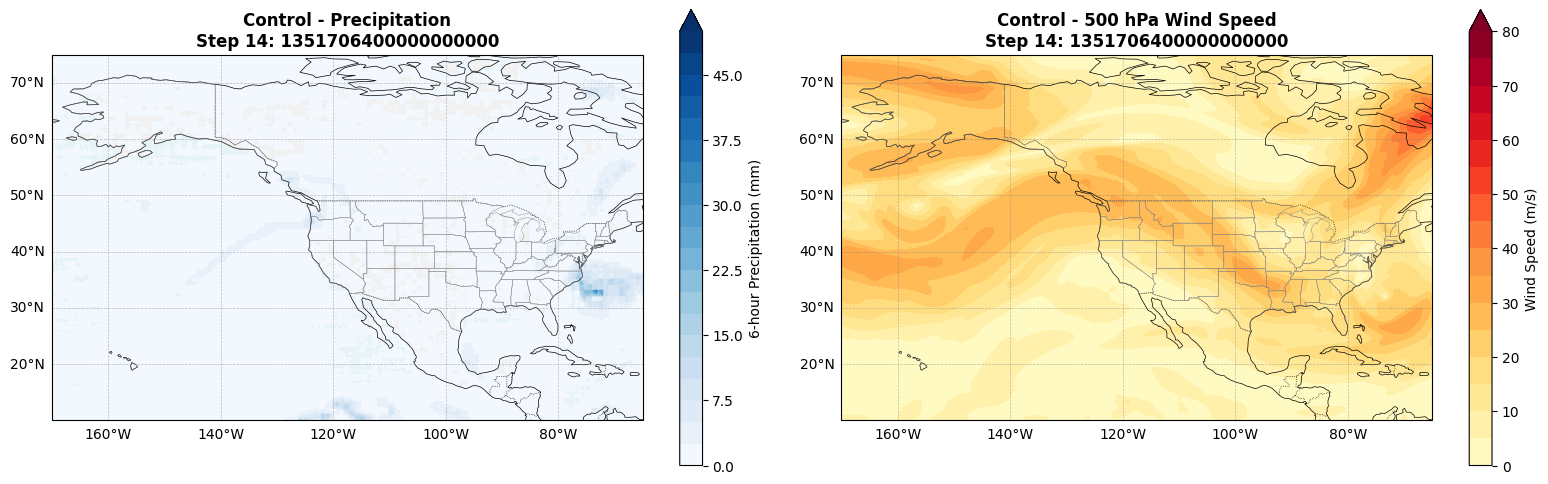

In [5]:
# Subset for North America
precip_ctrl_sub, lat_sub, lon_sub, extent = subset_north_america(precip_control, lat, lon, REGION)
wind_ctrl_sub, _, _, _ = subset_north_america(wind_control, lat, lon, REGION)

# Convert precipitation to mm
precip_ctrl_mm = precip_ctrl_sub * 1000

# Create figure
fig = plt.figure(figsize=(16, 6))
lon_grid, lat_grid = np.meshgrid(lon_sub, lat_sub)

# Precipitation
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
setup_north_america_map(ax1, extent)
cf1 = ax1.contourf(lon_grid, lat_grid, precip_ctrl_mm,
                   levels=np.arange(0, 50.5, 2.5), cmap='Blues',
                   extend='max', transform=ccrs.PlateCarree())
plt.colorbar(cf1, ax=ax1, label='6-hour Precipitation (mm)', shrink=0.8)
ax1.set_title(f'Control - Precipitation\nStep {STEP_TO_PLOT}: {time_str}',
              fontsize=12, fontweight='bold')

# Wind
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
setup_north_america_map(ax2, extent)
cf2 = ax2.contourf(lon_grid, lat_grid, wind_ctrl_sub,
                   levels=np.arange(0, 80.5, 5), cmap='YlOrRd',
                   extend='max', transform=ccrs.PlateCarree())
plt.colorbar(cf2, ax=ax2, label='Wind Speed (m/s)', shrink=0.8)
ax2.set_title(f'Control - 500 hPa Wind Speed\nStep {STEP_TO_PLOT}: {time_str}',
              fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Plot Perturbed Simulation

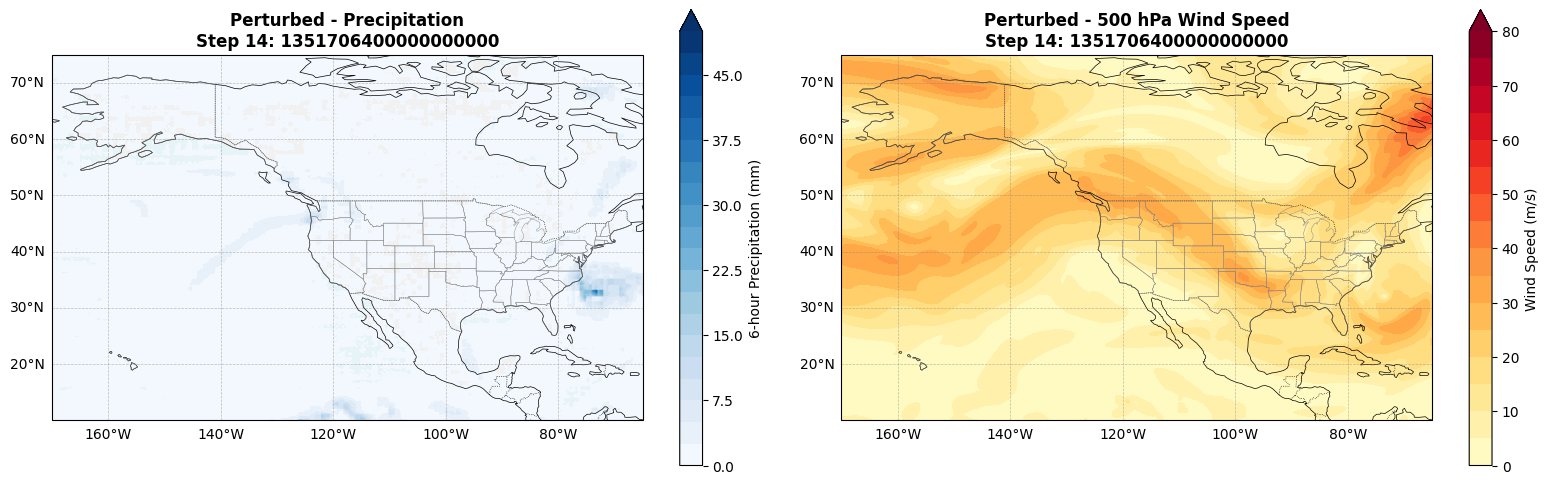

In [6]:
# Subset for North America
precip_pert_sub, _, _, _ = subset_north_america(precip_perturbed, lat, lon, REGION)
wind_pert_sub, _, _, _ = subset_north_america(wind_perturbed, lat, lon, REGION)

# Convert precipitation to mm
precip_pert_mm = precip_pert_sub * 1000

# Create figure
fig = plt.figure(figsize=(16, 6))

# Precipitation
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
setup_north_america_map(ax1, extent)
cf1 = ax1.contourf(lon_grid, lat_grid, precip_pert_mm,
                   levels=np.arange(0, 50.5, 2.5), cmap='Blues',
                   extend='max', transform=ccrs.PlateCarree())
plt.colorbar(cf1, ax=ax1, label='6-hour Precipitation (mm)', shrink=0.8)
ax1.set_title(f'Perturbed - Precipitation\nStep {STEP_TO_PLOT}: {time_str}',
              fontsize=12, fontweight='bold')

# Wind
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
setup_north_america_map(ax2, extent)
cf2 = ax2.contourf(lon_grid, lat_grid, wind_pert_sub,
                   levels=np.arange(0, 80.5, 5), cmap='YlOrRd',
                   extend='max', transform=ccrs.PlateCarree())
plt.colorbar(cf2, ax=ax2, label='Wind Speed (m/s)', shrink=0.8)
ax2.set_title(f'Perturbed - 500 hPa Wind Speed\nStep {STEP_TO_PLOT}: {time_str}',
              fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Plot Differences (Perturbed - Control)

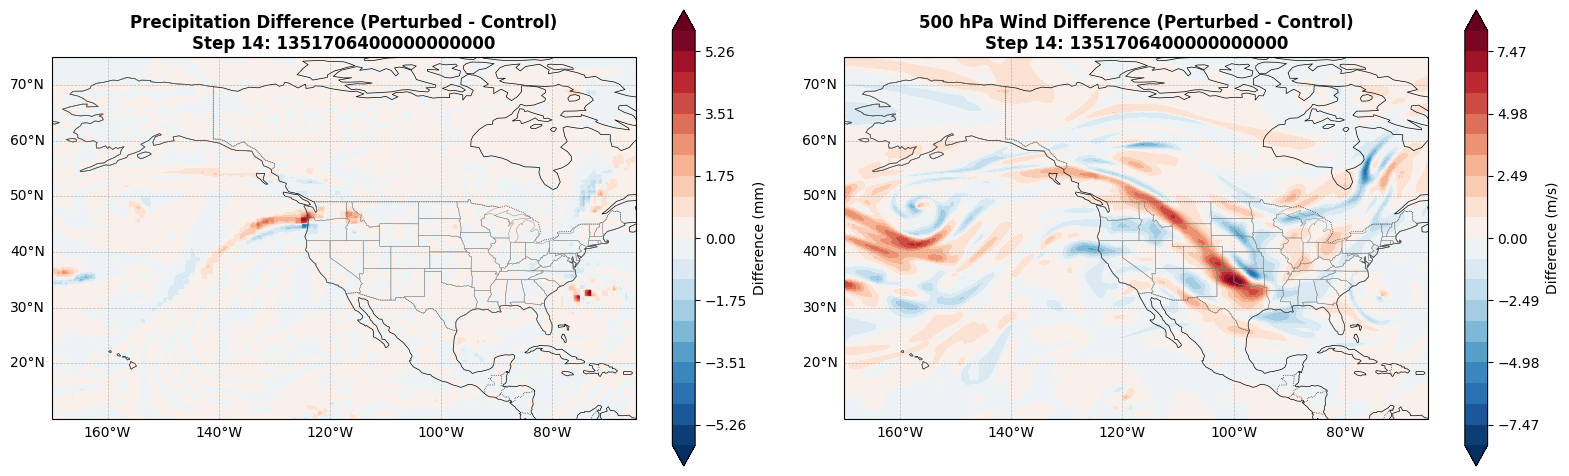


Difference Statistics for Step 14:
Precipitation (mm):
  Min: -4.35
  Max: 5.84
  Mean: -0.00
  Std: 0.25

500 hPa Wind Speed (m/s):
  Min: -6.71
  Max: 8.30
  Mean: 0.05
  Std: 1.07


In [7]:
# Calculate differences
precip_diff_mm = precip_pert_mm - precip_ctrl_mm
wind_diff = wind_pert_sub - wind_ctrl_sub

# Create figure
fig = plt.figure(figsize=(16, 6))

# Precipitation difference
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
setup_north_america_map(ax1, extent)
max_diff_precip = max(abs(precip_diff_mm.min()), abs(precip_diff_mm.max()))
levels_diff = np.linspace(-max_diff_precip, max_diff_precip, 21)
cf1 = ax1.contourf(lon_grid, lat_grid, precip_diff_mm,
                   levels=levels_diff, cmap='RdBu_r',
                   extend='both', transform=ccrs.PlateCarree())
plt.colorbar(cf1, ax=ax1, label='Difference (mm)', shrink=0.8)
ax1.set_title(f'Precipitation Difference (Perturbed - Control)\nStep {STEP_TO_PLOT}: {time_str}',
              fontsize=12, fontweight='bold')

# Wind difference
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
setup_north_america_map(ax2, extent)
max_diff_wind = max(abs(wind_diff.min()), abs(wind_diff.max()))
levels_diff_wind = np.linspace(-max_diff_wind, max_diff_wind, 21)
cf2 = ax2.contourf(lon_grid, lat_grid, wind_diff,
                   levels=levels_diff_wind, cmap='RdBu_r',
                   extend='both', transform=ccrs.PlateCarree())
plt.colorbar(cf2, ax=ax2, label='Difference (m/s)', shrink=0.8)
ax2.set_title(f'500 hPa Wind Difference (Perturbed - Control)\nStep {STEP_TO_PLOT}: {time_str}',
              fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nDifference Statistics for Step {STEP_TO_PLOT}:")
print(f"Precipitation (mm):")
print(f"  Min: {precip_diff_mm.min():.2f}")
print(f"  Max: {precip_diff_mm.max():.2f}")
print(f"  Mean: {precip_diff_mm.mean():.2f}")
print(f"  Std: {precip_diff_mm.std():.2f}")
print(f"\n500 hPa Wind Speed (m/s):")
print(f"  Min: {wind_diff.min():.2f}")
print(f"  Max: {wind_diff.max():.2f}")
print(f"  Mean: {wind_diff.mean():.2f}")
print(f"  Std: {wind_diff.std():.2f}")

## 4. Create Full Comparison Figure

Use the built-in comparison function to create a comprehensive 2x3 layout

In [8]:
# Create output directory for saved figures
output_dir = Path('/content/drive/MyDrive/Research/aurora-lite-decoder-perturbation/figures')
output_dir.mkdir(parents=True, exist_ok=True)

# Create comparison figure for a specific step
comparison_path = create_comparison_figure(
    control_results=control_results,
    perturbed_results=perturbed_results,
    step_num=STEP_TO_PLOT,
    output_dir=output_dir,
    region=REGION,
    dpi=150
)

print(f"\n✓ Comparison figure saved to: {comparison_path}")

Saved comparison figure: /content/drive/MyDrive/Research/aurora-lite-decoder-perturbation/figures/comparison_step_014.png

✓ Comparison figure saved to: /content/drive/MyDrive/Research/aurora-lite-decoder-perturbation/figures/comparison_step_014.png


## 5. Time Series Analysis

### Plot evolution of differences over time

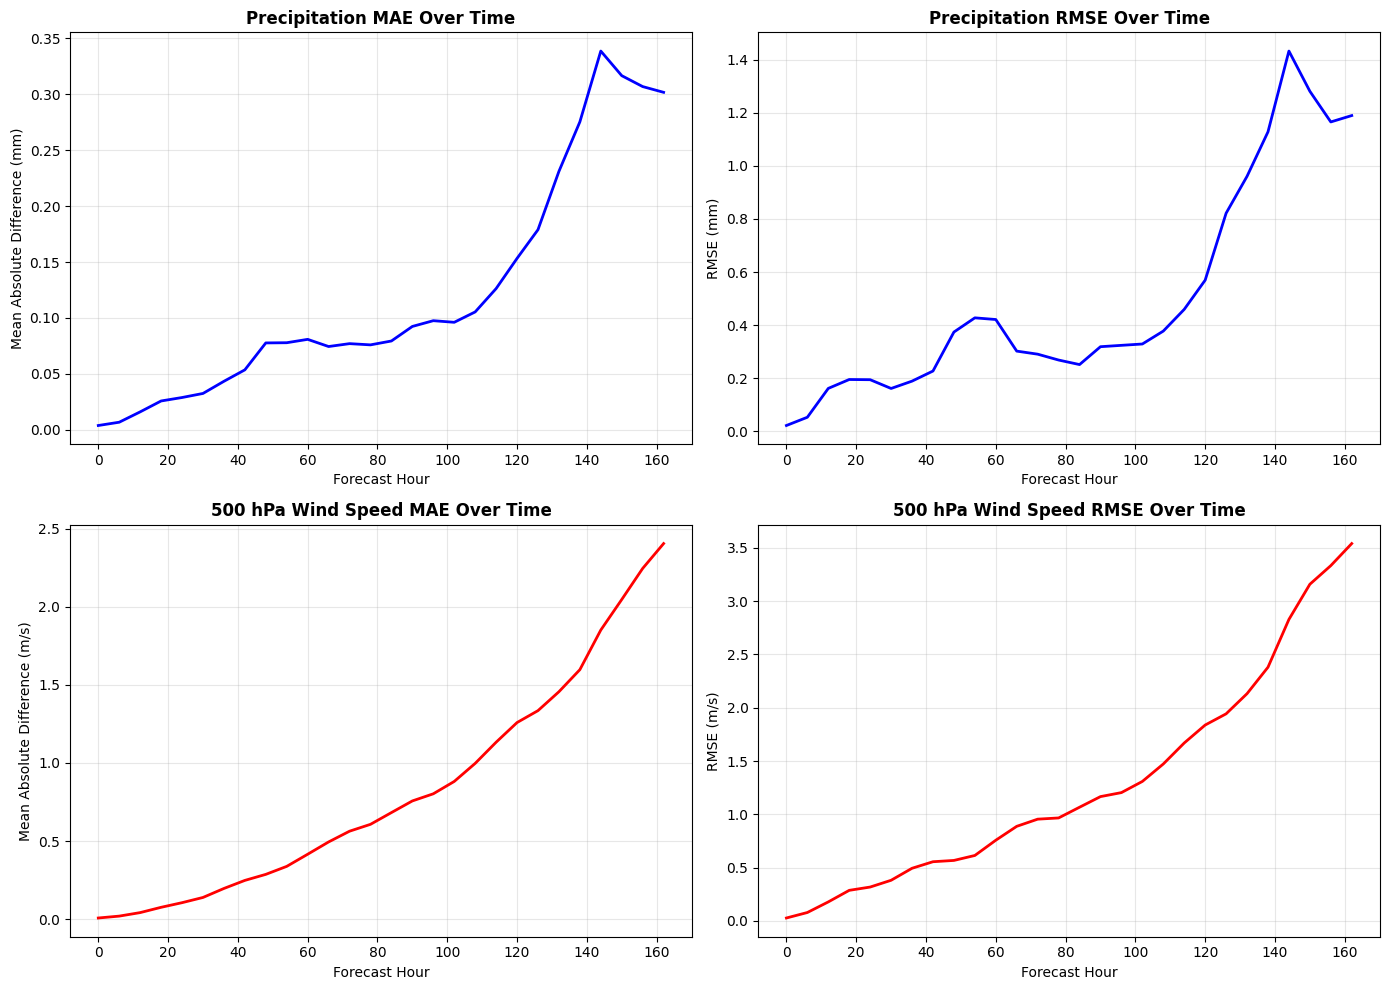


✓ Time series plot saved to: /content/drive/MyDrive/Research/aurora-lite-decoder-perturbation/figures/timeseries_differences.png


In [9]:
# Calculate area-averaged differences for each timestep
precip_diff_timeseries = []
wind_diff_timeseries = []
precip_rmse_timeseries = []
wind_rmse_timeseries = []

for step in range(len(control_results['precip'])):
    # Get data
    p_ctrl = control_results['precip'][step]
    p_pert = perturbed_results['precip'][step]
    w_ctrl = control_results['wind_speed_500'][step]
    w_pert = perturbed_results['wind_speed_500'][step]

    # Subset for region
    p_ctrl_sub, _, _, _ = subset_north_america(p_ctrl, lat, lon, REGION)
    p_pert_sub, _, _, _ = subset_north_america(p_pert, lat, lon, REGION)
    w_ctrl_sub, _, _, _ = subset_north_america(w_ctrl, lat, lon, REGION)
    w_pert_sub, _, _, _ = subset_north_america(w_pert, lat, lon, REGION)

    # Calculate differences
    p_diff = (p_pert_sub - p_ctrl_sub) * 1000  # Convert to mm
    w_diff = w_pert_sub - w_ctrl_sub

    # Statistics
    precip_diff_timeseries.append(np.mean(np.abs(p_diff)))
    wind_diff_timeseries.append(np.mean(np.abs(w_diff)))
    precip_rmse_timeseries.append(np.sqrt(np.mean(p_diff**2)))
    wind_rmse_timeseries.append(np.sqrt(np.mean(w_diff**2)))

# Convert times to hours since start
times = control_results['times']
hours = np.arange(0, len(times) * 6, 6)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Precipitation MAE
axes[0, 0].plot(hours, precip_diff_timeseries, 'b-', linewidth=2)
axes[0, 0].set_xlabel('Forecast Hour')
axes[0, 0].set_ylabel('Mean Absolute Difference (mm)')
axes[0, 0].set_title('Precipitation MAE Over Time', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Precipitation RMSE
axes[0, 1].plot(hours, precip_rmse_timeseries, 'b-', linewidth=2)
axes[0, 1].set_xlabel('Forecast Hour')
axes[0, 1].set_ylabel('RMSE (mm)')
axes[0, 1].set_title('Precipitation RMSE Over Time', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Wind MAE
axes[1, 0].plot(hours, wind_diff_timeseries, 'r-', linewidth=2)
axes[1, 0].set_xlabel('Forecast Hour')
axes[1, 0].set_ylabel('Mean Absolute Difference (m/s)')
axes[1, 0].set_title('500 hPa Wind Speed MAE Over Time', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Wind RMSE
axes[1, 1].plot(hours, wind_rmse_timeseries, 'r-', linewidth=2)
axes[1, 1].set_xlabel('Forecast Hour')
axes[1, 1].set_ylabel('RMSE (m/s)')
axes[1, 1].set_title('500 hPa Wind Speed RMSE Over Time', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'timeseries_differences.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Time series plot saved to: {output_dir / 'timeseries_differences.png'}")

## 7. Save Figures for All Steps (Optional)

**Warning:** This will create many files (2 per step)

**Note:** You can use `precip_log_scale=True` for logarithmic precipitation scale

In [11]:
# Uncomment to save all steps
from save_step_figures import save_all_steps

# Save control figures
control_fig_dir = output_dir / 'control_steps'
save_all_steps(control_results, control_fig_dir, prefix='control', region=REGION, precip_log_scale=True)

# Save perturbed figures
perturbed_fig_dir = output_dir / 'perturbed_steps'
save_all_steps(perturbed_results, perturbed_fig_dir, prefix='perturbed', region=REGION, precip_log_scale=True)

# With log scale for precipitation:
# save_all_steps(control_results, control_fig_dir, prefix='control', region=REGION, precip_log_scale=True)

print("\n✓ All step figures saved!")


Saving figures to: /content/drive/MyDrive/Research/aurora-lite-decoder-perturbation/figures/control_steps
Total steps: 28
  Saved step 5/28
  Saved step 10/28
  Saved step 15/28
  Saved step 20/28
  Saved step 25/28
✓ All figures saved! Total: 28 files

Saving figures to: /content/drive/MyDrive/Research/aurora-lite-decoder-perturbation/figures/perturbed_steps
Total steps: 28
  Saved step 5/28
  Saved step 10/28
  Saved step 15/28
  Saved step 20/28
  Saved step 25/28
✓ All figures saved! Total: 28 files

✓ All step figures saved!


In [ ]:
## 8. Save Comparison Figures for Multiple Steps

## 6. Save All Difference Figures

Save difference plots (perturbed - control) for every timestep

## 7. Save Comparison Figures for Multiple Steps

In [12]:
# Save comparison figures for specific steps
# steps_to_save = [0, 7, 14, 21, 27]  # Day 0, 1.75, 3.5, 5.25, 6.75
steps_to_save = list(range(27))

comparison_dir = output_dir / 'comparisons'
comparison_dir.mkdir(exist_ok=True)

for step in steps_to_save:
    if step < len(control_results['precip']):
        create_comparison_figure(
            control_results=control_results,
            perturbed_results=perturbed_results,
            step_num=step,
            output_dir=comparison_dir,
            region=REGION,
            dpi=150
        )

print(f"\n✓ Comparison figures saved for {len(steps_to_save)} steps")

Saved comparison figure: /content/drive/MyDrive/Research/aurora-lite-decoder-perturbation/figures/comparisons/comparison_step_000.png
Saved comparison figure: /content/drive/MyDrive/Research/aurora-lite-decoder-perturbation/figures/comparisons/comparison_step_001.png
Saved comparison figure: /content/drive/MyDrive/Research/aurora-lite-decoder-perturbation/figures/comparisons/comparison_step_002.png
Saved comparison figure: /content/drive/MyDrive/Research/aurora-lite-decoder-perturbation/figures/comparisons/comparison_step_003.png
Saved comparison figure: /content/drive/MyDrive/Research/aurora-lite-decoder-perturbation/figures/comparisons/comparison_step_004.png
Saved comparison figure: /content/drive/MyDrive/Research/aurora-lite-decoder-perturbation/figures/comparisons/comparison_step_005.png
Saved comparison figure: /content/drive/MyDrive/Research/aurora-lite-decoder-perturbation/figures/comparisons/comparison_step_006.png
Saved comparison figure: /content/drive/MyDrive/Research/auror